# 10. Temporal Analysis

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Real data path on the cluster
DATA_DIR = Path('/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor')

# Output paths
RESULTS_DIR = Path('/baldig/bioprojects2/emartinl/chemores/results/temporal_file_level')
FIGURES_DIR = Path('/baldig/bioprojects2/emartinl/chemores/figures/temporal_file_level')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Phasor-unmixed channels
CHANNELS = [
    "LipiBlue",
    "342",
    "BODIPY",
    "pHrodo",
    "TMRM",
    "Lyso",
    "Tubulin",
]

# Files used in the thesis
FILE_INFO = [
    # name              group              session
    ('CNTL-MB231',     'Control',         'session_orig'),
    ('TAMO-MB231',     'Chemoresistant',  'session_orig'),
    ('CNTL_75uM_p1',   'Control',         'session_75uM'),
    ('CNTL_75uM_p2',   'Control',         'session_75uM'),
    ('CNTL_75uM_p3',   'Control',         'session_75uM'),
    ('CNTL_75uM_p4',   'Control',         'session_75uM'),
    ('TAMO_p1',        'Chemoresistant',  'session_tamo_new'),
    ('TAMO_p2',        'Chemoresistant',  'session_tamo_new'),
]

manifest = pd.DataFrame(FILE_INFO, columns=["file", "group", "session"])

manifest["cells_path"] = manifest["file"].apply(lambda x: DATA_DIR / f"{x}_cells.npy")
manifest["meta_path"] = manifest["file"].apply(lambda x: DATA_DIR / f"{x}_cells_meta.csv")

manifest

,file,group,session,cells_path,meta_path
0,CNTL-MB231,Control,session_orig,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
1,TAMO-MB231,Chemoresistant,session_orig,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
2,CNTL_75uM_p1,Control,session_75uM,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
3,CNTL_75uM_p2,Control,session_75uM,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
4,CNTL_75uM_p3,Control,session_75uM,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
5,CNTL_75uM_p4,Control,session_75uM,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
6,TAMO_p1,Chemoresistant,session_tamo_new,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...
7,TAMO_p2,Chemoresistant,session_tamo_new,/baldig/bioprojects2/emartinl/chemores/preproc...,/baldig/bioprojects2/emartinl/chemores/preproc...


In [2]:
manifest["cells_exists"] = manifest["cells_path"].apply(lambda p: p.exists())
manifest["meta_exists"] = manifest["meta_path"].apply(lambda p: p.exists())

manifest[["file", "group", "session", "cells_exists", "meta_exists"]]

,file,group,session,cells_exists,meta_exists
0,CNTL-MB231,Control,session_orig,True,True
1,TAMO-MB231,Chemoresistant,session_orig,True,True
2,CNTL_75uM_p1,Control,session_75uM,True,True
3,CNTL_75uM_p2,Control,session_75uM,True,True
4,CNTL_75uM_p3,Control,session_75uM,True,True
5,CNTL_75uM_p4,Control,session_75uM,True,True
6,TAMO_p1,Chemoresistant,session_tamo_new,True,True
7,TAMO_p2,Chemoresistant,session_tamo_new,True,True


In [3]:
coverage_rows = []

for _, row in manifest.iterrows():
    meta = pd.read_csv(row["meta_path"])
    X = np.load(row["cells_path"], mmap_mode="r")

    coverage_rows.append({
        "file": row["file"],
        "group": row["group"],
        "session": row["session"],
        "n_cells_meta": len(meta),
        "n_cells_array": X.shape[0],
        "array_shape": str(X.shape),
        "n_timepoints": meta["time"].nunique(),
        "min_timepoint": meta["time"].min(),
        "max_timepoint": meta["time"].max(),
        "n_tiles": meta["tile"].nunique() if "tile" in meta.columns else np.nan,
    })

coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(RESULTS_DIR / "file_temporal_coverage.csv", index=False)
coverage

,file,group,session,n_cells_meta,n_cells_array,array_shape,n_timepoints,min_timepoint,max_timepoint,n_tiles
0,CNTL-MB231,Control,session_orig,4500,4500,"(4500, 7, 512, 512)",15,0,14,25
1,TAMO-MB231,Chemoresistant,session_orig,5750,5750,"(5750, 7, 512, 512)",15,0,14,25
2,CNTL_75uM_p1,Control,session_75uM,6012,6012,"(6012, 7, 512, 512)",24,0,23,9
3,CNTL_75uM_p2,Control,session_75uM,3231,3231,"(3231, 7, 512, 512)",24,0,23,9
4,CNTL_75uM_p3,Control,session_75uM,4131,4131,"(4131, 7, 512, 512)",24,0,23,9
5,CNTL_75uM_p4,Control,session_75uM,1692,1692,"(1692, 7, 512, 512)",24,0,23,9
6,TAMO_p1,Chemoresistant,session_tamo_new,11900,11900,"(11900, 7, 512, 512)",24,0,23,25
7,TAMO_p2,Chemoresistant,session_tamo_new,9725,9725,"(9725, 7, 512, 512)",24,0,23,25


In [4]:
import torch

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def compute_file_channel_trajectory_gpu(file_name, group, session, batch_size=128):
    """
    Computes mean intensity per file, timepoint and channel.
    Uses GPU for batch reductions, but data are still loaded from disk through NumPy.
    """
    meta_path = DATA_DIR / f"{file_name}_cells_meta.csv"
    cells_path = DATA_DIR / f"{file_name}_cells.npy"

    meta = pd.read_csv(meta_path)
    X = np.load(cells_path, mmap_mode="r")  # shape: N x 7 x H x W

    rows = []

    for t in sorted(meta["time"].unique()):
        idx = np.where(meta["time"].values == t)[0]

        if len(idx) == 0:
            continue

        channel_sum = torch.zeros(len(CHANNELS), dtype=torch.float64, device=DEVICE)
        pixel_count = 0

        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]

            # Load from disk/RAM into CPU first
            X_batch_np = np.asarray(X[batch_idx], dtype=np.float32)

            # Move to GPU
            X_batch = torch.from_numpy(X_batch_np).to(DEVICE, non_blocking=True)

            # Sum over cells and spatial dimensions
            channel_sum += X_batch.sum(dim=(0, 2, 3)).double()
            pixel_count += X_batch.shape[0] * X_batch.shape[2] * X_batch.shape[3]

            del X_batch, X_batch_np

        channel_means = (channel_sum / pixel_count).detach().cpu().numpy()

        for c_idx, channel in enumerate(CHANNELS):
            rows.append({
                "file": file_name,
                "group": group,
                "session": session,
                "time": int(t),
                "channel": channel,
                "mean_intensity": float(channel_means[c_idx]),
                "n_cells": len(idx),
            })

        print(f"{file_name:20s} t={t:02d} cells={len(idx):5d}", flush=True)

    return pd.DataFrame(rows)

Using device: cuda:0


In [5]:
trajectory_dfs = []

for name, group, session in FILE_INFO:
    print(f"Processing {name}...")
    df_file = compute_file_channel_trajectory_gpu(
        name, group, session, batch_size=128
    )
    trajectory_dfs.append(df_file)

trajectories = pd.concat(trajectory_dfs, ignore_index=True)
trajectories.to_csv(RESULTS_DIR / "file_channel_mean_trajectories.csv", index=False)

trajectories.head()

Processing CNTL-MB231...
CNTL-MB231           t=00 cells=  325
CNTL-MB231           t=01 cells=  300
CNTL-MB231           t=02 cells=  425
CNTL-MB231           t=03 cells=  250
CNTL-MB231           t=04 cells=  250
CNTL-MB231           t=05 cells=  225
CNTL-MB231           t=06 cells=  250
CNTL-MB231           t=07 cells=  200
CNTL-MB231           t=08 cells=  275
CNTL-MB231           t=09 cells=  300
CNTL-MB231           t=10 cells=  325
CNTL-MB231           t=11 cells=  325
CNTL-MB231           t=12 cells=  300
CNTL-MB231           t=13 cells=  350
CNTL-MB231           t=14 cells=  400
Processing TAMO-MB231...
TAMO-MB231           t=00 cells=  350
TAMO-MB231           t=01 cells=  350
TAMO-MB231           t=02 cells=  525
TAMO-MB231           t=03 cells=  400
TAMO-MB231           t=04 cells=  250
TAMO-MB231           t=05 cells=  350
TAMO-MB231           t=06 cells=  300
TAMO-MB231           t=07 cells=  275
TAMO-MB231           t=08 cells=  375
TAMO-MB231           t=09 cells=  350


,file,group,session,time,channel,mean_intensity,n_cells
0,CNTL-MB231,Control,session_orig,0,LipiBlue,0.480979,325
1,CNTL-MB231,Control,session_orig,0,342,1.768222,325
2,CNTL-MB231,Control,session_orig,0,BODIPY,0.779663,325
3,CNTL-MB231,Control,session_orig,0,pHrodo,0.446133,325
4,CNTL-MB231,Control,session_orig,0,TMRM,0.436525,325


In [6]:
trajectories.shape

(1218, 7)

In [7]:
trajectories.head(10)

,file,group,session,time,channel,mean_intensity,n_cells
0,CNTL-MB231,Control,session_orig,0,LipiBlue,0.480979,325
1,CNTL-MB231,Control,session_orig,0,342,1.768222,325
2,CNTL-MB231,Control,session_orig,0,BODIPY,0.779663,325
3,CNTL-MB231,Control,session_orig,0,pHrodo,0.446133,325
4,CNTL-MB231,Control,session_orig,0,TMRM,0.436525,325
5,CNTL-MB231,Control,session_orig,0,Lyso,0.365630,325
6,CNTL-MB231,Control,session_orig,0,Tubulin,2.167978,325
7,CNTL-MB231,Control,session_orig,1,LipiBlue,0.419105,300
8,CNTL-MB231,Control,session_orig,1,342,1.372660,300
9,CNTL-MB231,Control,session_orig,1,BODIPY,0.685335,300


In [8]:
trajectories.groupby(["file", "channel"])["time"].agg(["min", "max", "nunique"]).reset_index()

,file,channel,min,max,nunique
0,CNTL-MB231,342,0,14,15
1,CNTL-MB231,BODIPY,0,14,15
2,CNTL-MB231,LipiBlue,0,14,15
3,CNTL-MB231,Lyso,0,14,15
4,CNTL-MB231,TMRM,0,14,15
5,CNTL-MB231,Tubulin,0,14,15
6,CNTL-MB231,pHrodo,0,14,15
7,CNTL_75uM_p1,342,0,23,24
8,CNTL_75uM_p1,BODIPY,0,23,24
9,CNTL_75uM_p1,LipiBlue,0,23,24


In [9]:
trajectories.groupby("file")["n_cells"].agg(["min", "max", "mean"]).reset_index()

,file,min,max,mean
0,CNTL-MB231,200,425,300.000000
1,CNTL_75uM_p1,63,909,250.500000
2,CNTL_75uM_p2,72,225,134.625000
3,CNTL_75uM_p3,108,324,172.125000
4,CNTL_75uM_p4,45,126,70.500000
5,TAMO-MB231,250,550,383.333333
6,TAMO_p1,350,925,495.833333
7,TAMO_p2,225,725,405.208333


### Fold change with respect to t0

In [10]:
def add_fold_change(df):
    df = df.copy()

    baseline = (
        df[df["time"] == 0]
        [["file", "channel", "mean_intensity"]]
        .rename(columns={"mean_intensity": "baseline_intensity"})
    )

    df = df.merge(baseline, on=["file", "channel"], how="left")

    df["fold_change"] = df["mean_intensity"] / (df["baseline_intensity"] + 1e-8)

    return df


trajectories_fc = add_fold_change(trajectories)

trajectories_fc.to_csv(
    RESULTS_DIR / "file_channel_fold_change_trajectories.csv",
    index=False
)

trajectories_fc.head()

,file,group,session,time,channel,mean_intensity,n_cells,baseline_intensity,fold_change
0,CNTL-MB231,Control,session_orig,0,LipiBlue,0.480979,325,0.480979,1.0
1,CNTL-MB231,Control,session_orig,0,342,1.768222,325,1.768222,1.0
2,CNTL-MB231,Control,session_orig,0,BODIPY,0.779663,325,0.779663,1.0
3,CNTL-MB231,Control,session_orig,0,pHrodo,0.446133,325,0.446133,1.0
4,CNTL-MB231,Control,session_orig,0,TMRM,0.436525,325,0.436525,1.0


In [11]:
trajectories_fc.groupby(["file", "channel"])["fold_change"].agg(["min", "max", "mean"]).reset_index()

,file,channel,min,max,mean
0,CNTL-MB231,342,0.427825,1.000000,0.743778
1,CNTL-MB231,BODIPY,0.529590,1.038781,0.761544
2,CNTL-MB231,LipiBlue,0.575551,1.000000,0.771542
3,CNTL-MB231,Lyso,0.439203,1.007624,0.712875
4,CNTL-MB231,TMRM,0.579764,1.083201,0.812372
5,CNTL-MB231,Tubulin,0.563086,1.103770,0.794897
6,CNTL-MB231,pHrodo,0.568569,1.099308,0.768460
7,CNTL_75uM_p1,342,0.099575,1.985988,0.881253
8,CNTL_75uM_p1,BODIPY,0.110118,2.058668,0.931831
9,CNTL_75uM_p1,LipiBlue,0.110323,3.132371,1.312633


### Exploratory figure

Original rows: 1218
Common-window rows: 840
           file  min  max  nunique
0    CNTL-MB231    0   14       15
1  CNTL_75uM_p1    0   14       15
2  CNTL_75uM_p2    0   14       15
3  CNTL_75uM_p3    0   14       15
4  CNTL_75uM_p4    0   14       15
5    TAMO-MB231    0   14       15
6       TAMO_p1    0   14       15
7       TAMO_p2    0   14       15


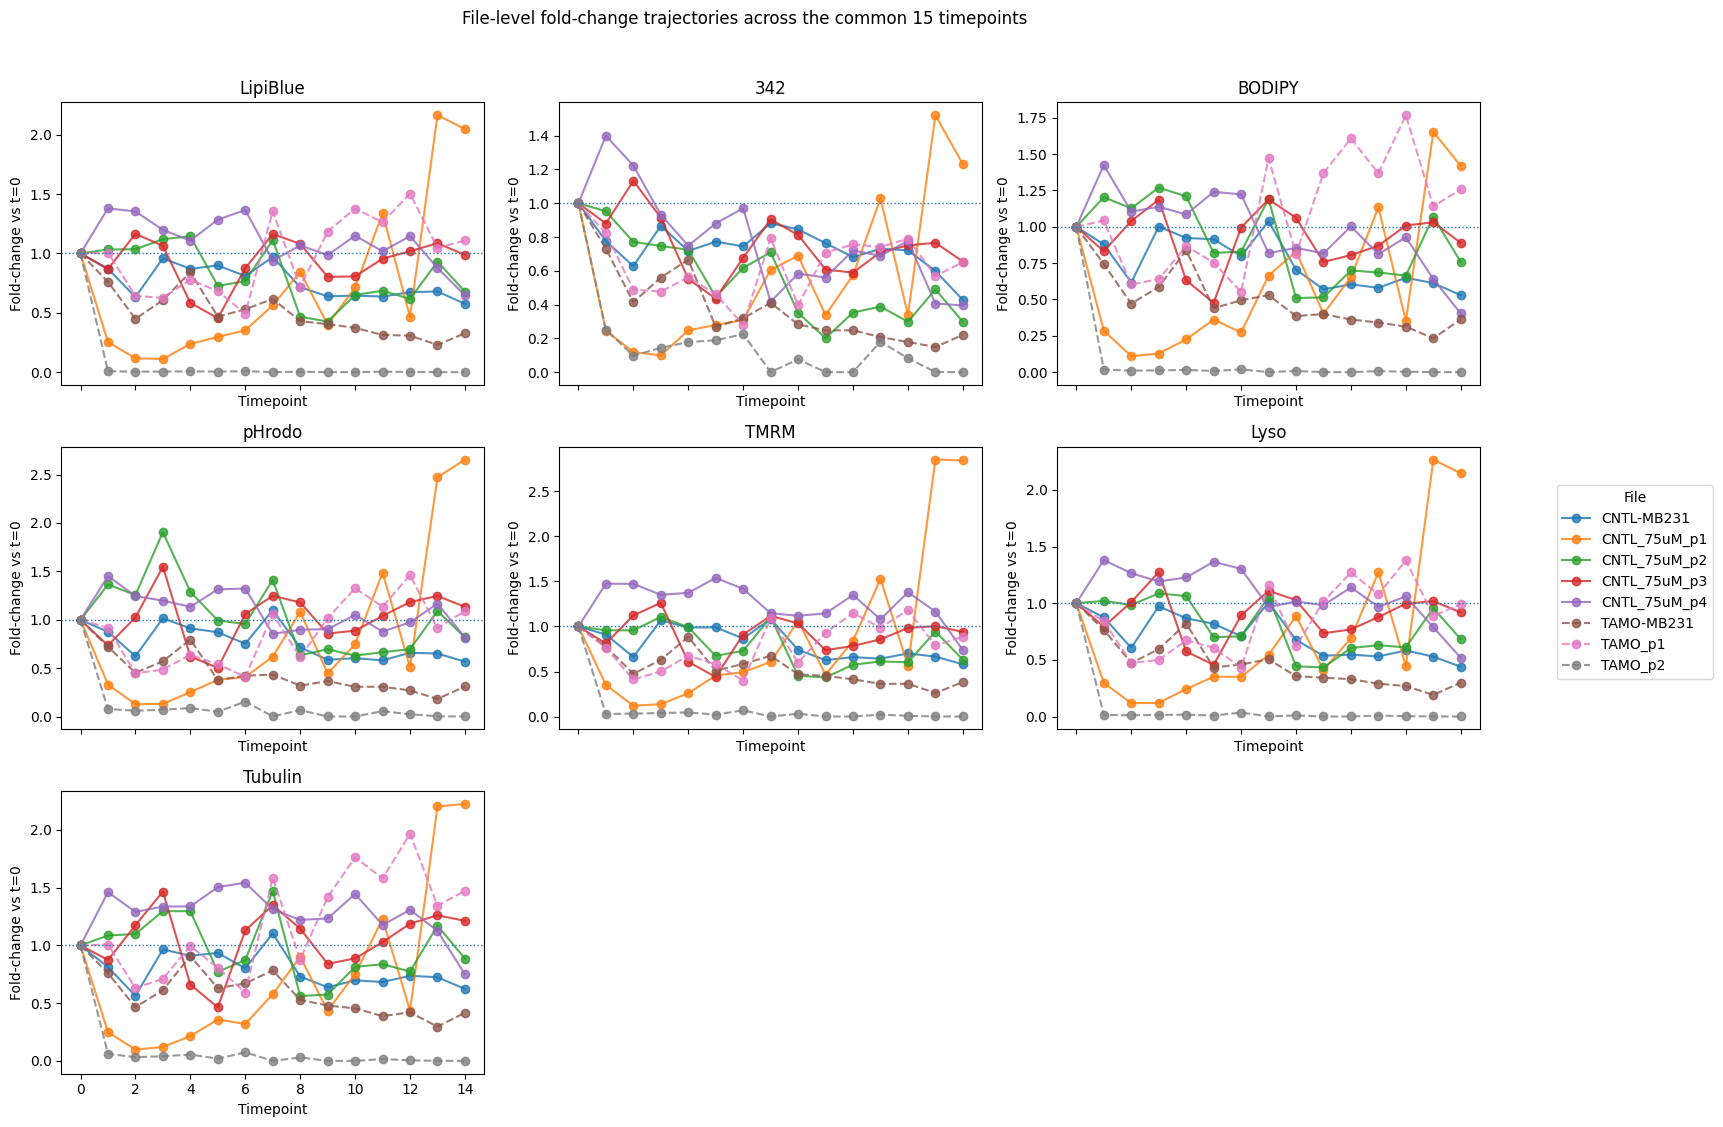

In [16]:
COMMON_MAX_T = 14

trajectories_fc_common = trajectories_fc[
    trajectories_fc["time"].between(0, COMMON_MAX_T)
].copy()

print("Original rows:", len(trajectories_fc))
print("Common-window rows:", len(trajectories_fc_common))
print(
    trajectories_fc_common
    .groupby("file")["time"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)

import matplotlib.pyplot as plt

def plot_all_fold_change_trajectories(df, save=True):
    """
    Plot fold-change trajectories for all files and channels using the common
    15-timepoint window t=0,...,14.
    """
    df = df[df["time"].between(0, COMMON_MAX_T)].copy()

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
    axes = axes.flatten()

    for i, channel in enumerate(CHANNELS):
        ax = axes[i]
        df_c = df[df["channel"] == channel]

        for file_name, df_f in df_c.groupby("file"):
            df_f = df_f.sort_values("time")
            group = df_f["group"].iloc[0]
            linestyle = "-" if group == "Control" else "--"

            ax.plot(
                df_f["time"],
                df_f["fold_change"],
                marker="o",
                linewidth=1.5,
                alpha=0.8,
                linestyle=linestyle,
                label=file_name
            )

        ax.axhline(1.0, linestyle=":", linewidth=1)
        ax.set_title(channel)
        ax.set_xlabel("Timepoint")
        ax.set_ylabel("Fold-change vs t=0")
        ax.set_xticks(range(0, COMMON_MAX_T + 1, 2))

    for j in range(len(CHANNELS), len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center right",
        bbox_to_anchor=(1.15, 0.5),
        title="File"
    )

    fig.suptitle(
        "File-level fold-change trajectories across the common 15 timepoints",
        y=1.02
    )

    plt.tight_layout()

    if save:
        fig.savefig(
            FIGURES_DIR / "all_file_level_fold_change_trajectories_common15.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


plot_all_fold_change_trajectories(trajectories_fc_common)

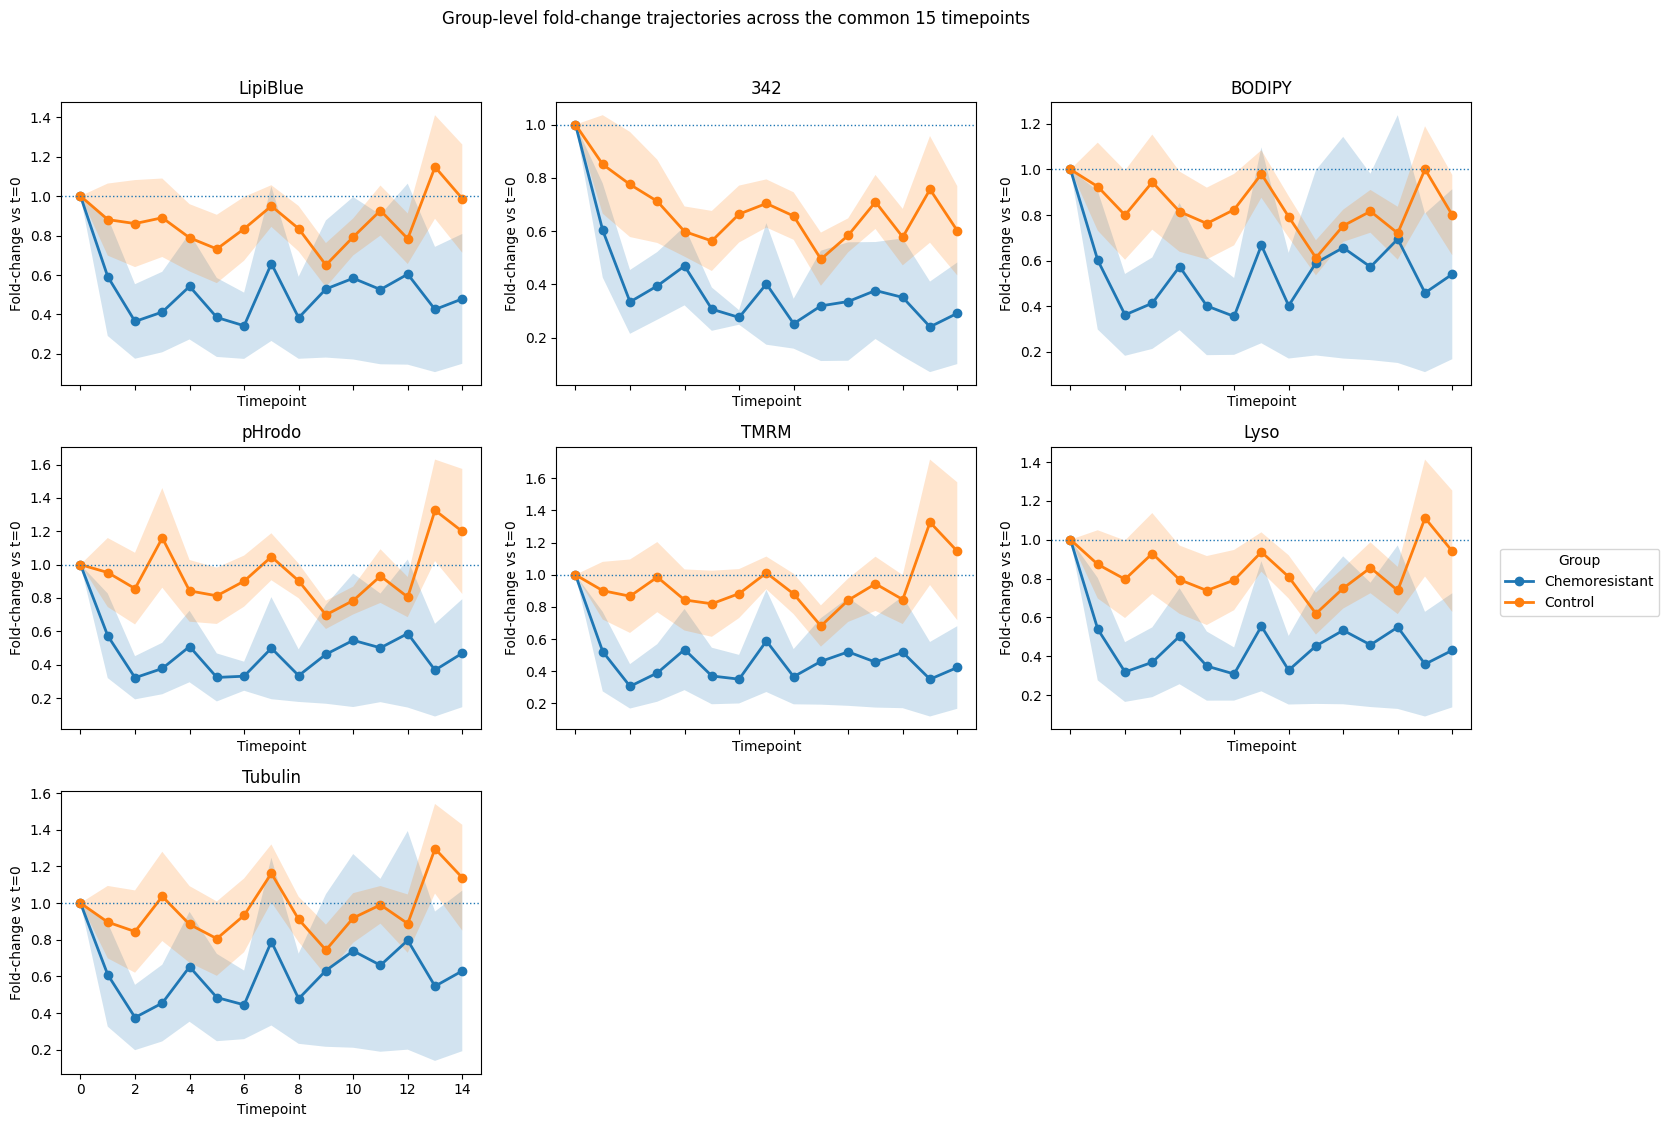

,group,channel,time,mean_fc,sd_fc,n_files,sem_fc
0,Chemoresistant,342,0,1.000000,1.820775e-09,3,1.051225e-09
1,Chemoresistant,342,1,0.602241,3.063626e-01,3,1.768785e-01
2,Chemoresistant,342,2,0.333829,2.076067e-01,3,1.198618e-01
3,Chemoresistant,342,3,0.394049,2.202709e-01,3,1.271735e-01
4,Chemoresistant,342,4,0.468822,2.563609e-01,3,1.480100e-01


In [17]:
def plot_group_mean_fold_change(df, save=True):
    """
    Plot group-level mean fold-change trajectories using the common
    15-timepoint window t=0,...,14.

    Each group trajectory is computed by averaging file-level trajectories.
    Shaded regions show SEM across files, not across individual cells.
    """
    df = df[df["time"].between(0, COMMON_MAX_T)].copy()

    summary = (
        df
        .groupby(["group", "channel", "time"])
        .agg(
            mean_fc=("fold_change", "mean"),
            sd_fc=("fold_change", "std"),
            n_files=("file", "nunique")
        )
        .reset_index()
    )

    summary["sem_fc"] = summary["sd_fc"] / np.sqrt(summary["n_files"])

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
    axes = axes.flatten()

    for i, channel in enumerate(CHANNELS):
        ax = axes[i]
        df_c = summary[summary["channel"] == channel]

        for group, df_g in df_c.groupby("group"):
            df_g = df_g.sort_values("time")

            ax.plot(
                df_g["time"],
                df_g["mean_fc"],
                marker="o",
                linewidth=2,
                label=group
            )

            ax.fill_between(
                df_g["time"],
                df_g["mean_fc"] - df_g["sem_fc"],
                df_g["mean_fc"] + df_g["sem_fc"],
                alpha=0.2
            )

        ax.axhline(1.0, linestyle=":", linewidth=1)
        ax.set_title(channel)
        ax.set_xlabel("Timepoint")
        ax.set_ylabel("Fold-change vs t=0")
        ax.set_xticks(range(0, COMMON_MAX_T + 1, 2))

    for j in range(len(CHANNELS), len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center right",
        bbox_to_anchor=(1.12, 0.5),
        title="Group"
    )

    fig.suptitle(
        "Group-level fold-change trajectories across the common 15 timepoints",
        y=1.02
    )

    plt.tight_layout()

    if save:
        fig.savefig(
            FIGURES_DIR / "group_mean_fold_change_all_channels_common15.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return summary


group_fc_summary = plot_group_mean_fold_change(trajectories_fc_common)

group_fc_summary.to_csv(
    RESULTS_DIR / "group_mean_fold_change_summary_common15.csv",
    index=False
)

group_fc_summary.head()

### What's happening with TAMO_p2 file?

In [18]:
# outlier detection (the TAMO_p2 file has a weird trajectory)
trajectories[
    trajectories["file"] == "TAMO_p2"
].sort_values(["channel", "time"]).head(80)

,file,group,session,time,channel,mean_intensity,n_cells
1051,TAMO_p2,Chemoresistant,session_tamo_new,0,342,1.598861,725
1058,TAMO_p2,Chemoresistant,session_tamo_new,1,342,0.403692,300
1065,TAMO_p2,Chemoresistant,session_tamo_new,2,342,0.156689,550
1072,TAMO_p2,Chemoresistant,session_tamo_new,3,342,0.230720,475
1079,TAMO_p2,Chemoresistant,session_tamo_new,4,342,0.286053,425
...,...,...,...,...,...,...,...
1076,TAMO_p2,Chemoresistant,session_tamo_new,3,Lyso,0.050775,475
1083,TAMO_p2,Chemoresistant,session_tamo_new,4,Lyso,0.060125,425
1090,TAMO_p2,Chemoresistant,session_tamo_new,5,Lyso,0.030360,400
1097,TAMO_p2,Chemoresistant,session_tamo_new,6,Lyso,0.127797,250


In [19]:
tamo_p2_abs = trajectories[
    trajectories["file"] == "TAMO_p2"
].pivot_table(
    index="time",
    columns="channel",
    values="mean_intensity"
)

tamo_p2_abs

channel,342,BODIPY,LipiBlue,Lyso,TMRM,Tubulin,pHrodo
time,,,,,,,
0,1.598861,3.933916,8.467978,3.628237,2.939187,4.940146,1.443695
1,0.403692,0.071829,0.066680,0.049618,0.081183,0.303761,0.114299
2,0.156689,0.041587,0.032657,0.040560,0.095767,0.162744,0.090264
3,0.230720,0.049213,0.040109,0.050775,0.115717,0.199793,0.104515
4,0.286053,0.061208,0.051817,0.060125,0.132162,0.273796,0.129930
5,0.302379,0.034331,0.040313,0.030360,0.063669,0.098839,0.074024
6,0.360893,0.074814,0.066599,0.127797,0.200559,0.365625,0.226337
7,0.001800,0.002971,0.001527,0.001702,0.002240,0.003579,0.006176
8,0.121909,0.032715,0.021992,0.034760,0.091521,0.147976,0.098129


In [20]:
trajectories[
    trajectories["file"] == "TAMO_p2"
].groupby("time")["n_cells"].first()

time
0     725
1     300
2     550
3     475
4     425
5     400
6     250
7     350
8     550
9     275
10    275
11    225
12    475
13    625
14    575
15    525
16    275
17    325
18    400
19    225
20    450
21    300
22    400
23    350
Name: n_cells, dtype: int64

In [21]:
tamo_abs = trajectories[
    trajectories["file"].isin(["TAMO_p1", "TAMO_p2"])
].pivot_table(
    index=["file", "time"],
    columns="channel",
    values="mean_intensity"
)

tamo_abs

channel            342    BODIPY  LipiBlue      Lyso      TMRM   Tubulin  \
file    time                                                               
TAMO_p1 0     3.507920  0.384250  0.389351  0.306666  0.731185  1.286748   
        1     2.887277  0.400880  0.391911  0.257434  0.556773  1.296011   
        2     1.715434  0.231791  0.249765  0.144914  0.301214  0.811223   
        3     1.674038  0.245902  0.243858  0.153147  0.366013  0.915377   
        4     1.971327  0.333289  0.303193  0.206033  0.493851  1.280162   
        5     1.623646  0.289761  0.265787  0.186283  0.425359  1.037625   
        6     0.983936  0.211832  0.191452  0.132214  0.292267  0.759744   
        7     2.778836  0.565375  0.527849  0.355004  0.797082  2.040413   
        8     1.390830  0.311836  0.279535  0.189968  0.437868  1.128989   
        9     2.484018  0.526312  0.460900  0.311391  0.681759  1.823475   
        10    2.654382  0.617641  0.536505  0.389800  0.839741  2.268102   
        11    2.598395  0.525538  0.491488  0.330475  0.721365  2.032558   
        12    2.773378  0.679212  0.585679  0.422433  0.864252  2.528491   
        13    1.997704  0.438574  0.407239  0.272025  0.576968  1.728613   
        14    2.283495  0.482813  0.431828  0.304193  0.649117  1.894432   
        15    2.118059  0.471746  0.432708  0.305335  0.613894  1.949872   
        16    1.089220  0.324771  0.312773  0.225891  0.448229  1.358943   
        17    1.965139  0.469158  0.408232  0.297539  0.582448  1.693743   
        18    1.931794  0.492113  0.458485  0.329663  0.660617  1.861916   
        19    2.266325  0.532880  0.484448  0.358265  0.704081  1.941129   
        20    2.294418  0.570676  0.503053  0.385289  0.754689  1.962040   
        21    2.278495  0.500321  0.483567  0.341636  0.666993  1.970124   
        22    1.521500  0.369987  0.337992  0.252100  0.491641  1.376791   
        23    1.176654  0.293852  0.288802  0.212559  0.413968  1.230629   
TAMO_p2 0     1.598861  3.933916  8.467978  3.628237  2.939187  4.940146   
        1     0.403692  0.071829  0.066680  0.049618  0.081183  0.303761   
        2     0.156689  0.041587  0.032657  0.040560  0.095767  0.162744   
        3     0.230720  0.049213  0.040109  0.050775  0.115717  0.199793   
        4     0.286053  0.061208  0.051817  0.060125  0.132162  0.273796   
        5     0.302379  0.034331  0.040313  0.030360  0.063669  0.098839   
        6     0.360893  0.074814  0.066599  0.127797  0.200559  0.365625   
        7     0.001800  0.002971  0.001527  0.001702  0.002240  0.003579   
        8     0.121909  0.032715  0.021992  0.034760  0.091521  0.147976   
        9     0.001238  0.002117  0.001145  0.001271  0.001390  0.003163   
        10    0.001313  0.002002  0.001061  0.001165  0.001349  0.002604   
        11    0.289489  0.029666  0.030890  0.029363  0.062600  0.078576   
        12    0.132446  0.012043  0.012812  0.011801  0.024154  0.026487   
        13    0.002410  0.002149  0.001257  0.001800  0.003065  0.004433   
        14    0.001220  0.002065  0.001184  0.001183  0.001495  0.003070   
        15    0.144588  0.014140  0.015521  0.010855  0.022014  0.030132   
        16    0.025302  0.021390  0.017416  0.018751  0.039290  0.098299   
        17    0.074518  0.021543  0.021183  0.014296  0.023439  0.074468   
        18    0.007009  0.007098  0.005056  0.004226  0.007538  0.015904   
        19    0.098850  0.039403  0.043696  0.034951  0.070932  0.135389   
        20    0.024712  0.008297  0.007903  0.007061  0.011569  0.030447   
        21    0.292417  0.045555  0.053515  0.035108  0.067294  0.152752   
        22    0.309639  0.049946  0.061926  0.042502  0.071514  0.160841   
        23    0.158155  0.042765  0.049966  0.040605  0.067894  0.142006   

channel         pHrodo  
file    time            
TAMO_p1 0     0.554178  
        1     0.509143  
        2     0.248339  
        3     0.269695  
        4     0.354464  
        5     0.299606  

In [22]:
# 1. Baseline t=0 across all files
baseline_compare = trajectories[
    trajectories["time"] == 0
].pivot_table(
    index="file",
    columns="channel",
    values="mean_intensity"
)

baseline_compare

channel,342,BODIPY,LipiBlue,Lyso,TMRM,Tubulin,pHrodo
file,,,,,,,
CNTL-MB231,1.768222,0.779663,0.480979,0.365630,0.436525,2.167978,0.446133
CNTL_75uM_p1,2.928755,0.518758,0.271986,0.220938,0.463210,0.944454,0.338267
CNTL_75uM_p2,1.805905,0.468042,0.295655,0.229460,0.491526,1.105318,0.356341
CNTL_75uM_p3,3.012268,0.350838,0.261988,0.216440,0.424257,0.625157,0.400445
CNTL_75uM_p4,0.641431,0.215189,0.146415,0.103141,0.179121,0.424650,0.151935
TAMO-MB231,2.914059,3.021474,1.084917,0.810243,0.886486,4.658926,1.381934
TAMO_p1,3.507920,0.384250,0.389351,0.306666,0.731185,1.286748,0.554178
TAMO_p2,1.598861,3.933916,8.467978,3.628237,2.939187,4.940146,1.443695


In [23]:
# 2. Cell counts per file/timepoint
cell_counts_pivot = (
    trajectories
    .groupby(["file", "time"])["n_cells"]
    .first()
    .reset_index()
    .pivot(index="time", columns="file", values="n_cells")
)

cell_counts_pivot

file,CNTL-MB231,CNTL_75uM_p1,CNTL_75uM_p2,CNTL_75uM_p3,CNTL_75uM_p4,TAMO-MB231,TAMO_p1,TAMO_p2
time,,,,,,,,
0,325.0,180.0,90.0,144.0,126.0,350.0,425.0,725.0
1,300.0,612.0,90.0,144.0,99.0,350.0,450.0,300.0
2,425.0,909.0,90.0,108.0,81.0,525.0,700.0,550.0
3,250.0,666.0,90.0,135.0,72.0,400.0,650.0,475.0
4,250.0,576.0,72.0,225.0,90.0,250.0,525.0,425.0
5,225.0,396.0,117.0,297.0,99.0,350.0,550.0,400.0
6,250.0,243.0,99.0,180.0,81.0,300.0,925.0,250.0
7,200.0,153.0,72.0,144.0,90.0,275.0,350.0,350.0
8,275.0,162.0,180.0,153.0,72.0,375.0,750.0,550.0


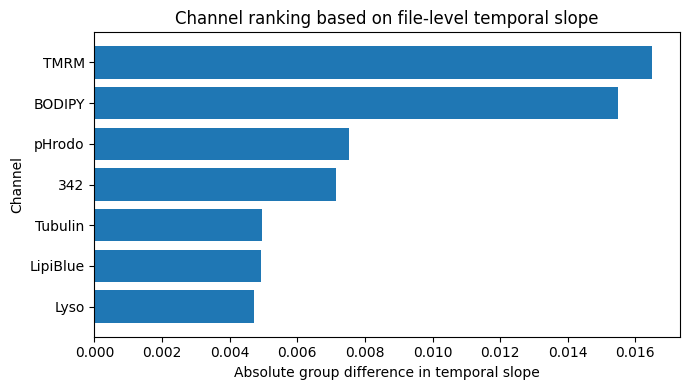

In [30]:
# ---------------------------------------------------------------------
# Plot channel ranking
# ---------------------------------------------------------------------

def plot_channel_ranking(ranking, save=True):
    ranking_plot = ranking.sort_values("abs_difference", ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        ranking_plot["channel"],
        ranking_plot["abs_difference"]
    )

    ax.set_xlabel("Absolute group difference in temporal slope")
    ax.set_ylabel("Channel")
    ax.set_title("Channel ranking based on file-level temporal slope")

    plt.tight_layout()

    if save:
        fig.savefig(
            FIGURES_DIR / "channel_ranking_slope_common15_clean.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


plot_channel_ranking(channel_rank_slope_clean)